
# Bioinformatics Assignment — Linear Filters and CNNs

**Name:** Jo Prisse Olfindo

**Course/Section:** DOES 1C3-DIT/DENG11G1 — Bioinformatics  

**Date:** September 9, 2026

This notebook answers Questions **1–6** from the assignment (CNN Activity) and includes executable examples for the image-filtering questions.

> **CNN assumption for Question 5:** The resized input is treated as an **RGB image**, so its shape is **256 × 256 × 3**.  
> Since the assignment says `padding = true`, this notebook interprets it as **SAME padding**. For SAME padding:
>
> \[
> H_{out}=\left\lceil\frac{H_{in}}{S}\right\rceil,\qquad
> W_{out}=\left\lceil\frac{W_{in}}{S}\right\rceil
> \]
>
> where \(S\) is the stride.


## Setup

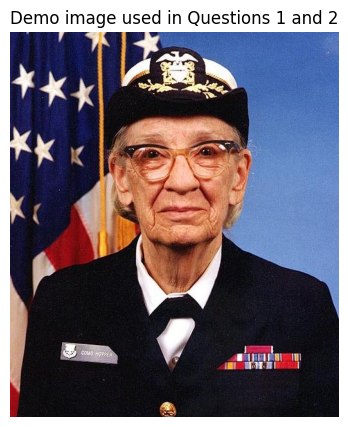

In [7]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cbook as cbook
from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = False

def load_demo_image():
    """Load a built-in Matplotlib portrait so the notebook runs without internet."""
    sample_path = cbook.get_sample_data("grace_hopper.jpg", asfileobj=False)
    image = np.asarray(Image.open(sample_path).convert("RGB"), dtype=np.float32) / 255.0
    return image

def convolve_rgb(image, kernel):
    """Apply the same 2-D linear kernel independently to each RGB channel."""
    kernel = np.asarray(kernel, dtype=np.float32)
    kh, kw = kernel.shape

    # These examples use odd-sized kernels, so symmetric padding is enough.
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image, ((ph, ph), (pw, pw), (0, 0)), mode="reflect")

    windows = sliding_window_view(padded, (kh, kw), axis=(0, 1))
    # windows shape: H x W x C x kh x kw
    filtered = np.tensordot(windows, kernel, axes=([3, 4], [0, 1]))
    return np.clip(filtered, 0.0, 1.0)

image = load_demo_image()

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Demo image used in Questions 1 and 2")
plt.axis("off")
plt.show()



## 1. Designing a Linear Filter to Brighten or Darken an Image

A simple **linear brightness filter** can multiply every pixel by a constant gain:

\[
g(x,y)=\alpha f(x,y)
\]

This is equivalent to a **1 × 1 convolution kernel**:

\[
K=[\alpha]
\]

- If \(\alpha > 1\), the image becomes **brighter**.
- If \(0 < \alpha < 1\), the image becomes **darker**.
- Pixel values must be clipped to the valid range after multiplication.

For example:

- Brighten: \(\alpha=1.35\)
- Darken: \(\alpha=0.60\)

> Strictly speaking, adding a constant brightness offset, \(g=f+b\), is an **affine** operation rather than a purely linear one. Multiplication by \(\alpha\) is linear.


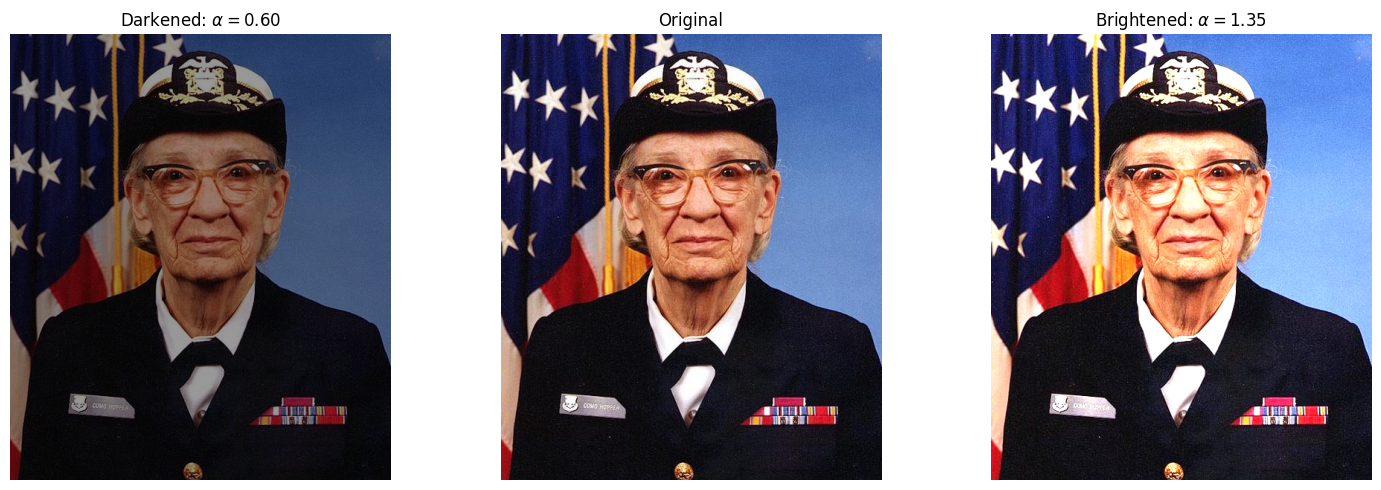

In [2]:

alpha_bright = 1.35
alpha_dark = 0.60

bright = np.clip(alpha_bright * image, 0, 1)
dark = np.clip(alpha_dark * image, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(dark)
axes[0].set_title(r"Darkened: $\alpha=0.60$")

axes[1].imshow(image)
axes[1].set_title("Original")

axes[2].imshow(bright)
axes[2].set_title(r"Brightened: $\alpha=1.35$")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()



### Answer

I would use a **gain filter** that scales every pixel intensity. A value larger than 1 brightens the image, while a value between 0 and 1 darkens it. Because it changes intensity without mixing neighboring pixels, it can be represented by a 1 × 1 linear filter. The result should be clipped so that values do not exceed the valid pixel range.



## 2. Designing a Linear Filter to Reduce Wrinkles or Blemishes

Wrinkles, small spots, and fine texture often contain relatively high spatial-frequency information. A **low-pass smoothing filter** reduces these rapid local changes.

A common linear choice is a **Gaussian filter**. A 3 × 3 approximation is:

\[
K_{3\times3}=
\frac{1}{16}
\begin{bmatrix}
1 & 2 & 1\\
2 & 4 & 2\\
1 & 2 & 1
\end{bmatrix}
\]

For stronger smoothing, a larger 5 × 5 Gaussian-like kernel can be used:

\[
K_{5\times5}
=
\frac{1}{256}
\begin{bmatrix}
1\\4\\6\\4\\1
\end{bmatrix}
\begin{bmatrix}
1&4&6&4&1
\end{bmatrix}
\]

The weights sum to 1, so average brightness is approximately preserved.

A larger smoothing kernel removes more fine detail, but it can also blur eyes, hair, edges, and other important features. In practical photo retouching, smoothing is therefore often applied only to selected skin regions rather than to the entire image.


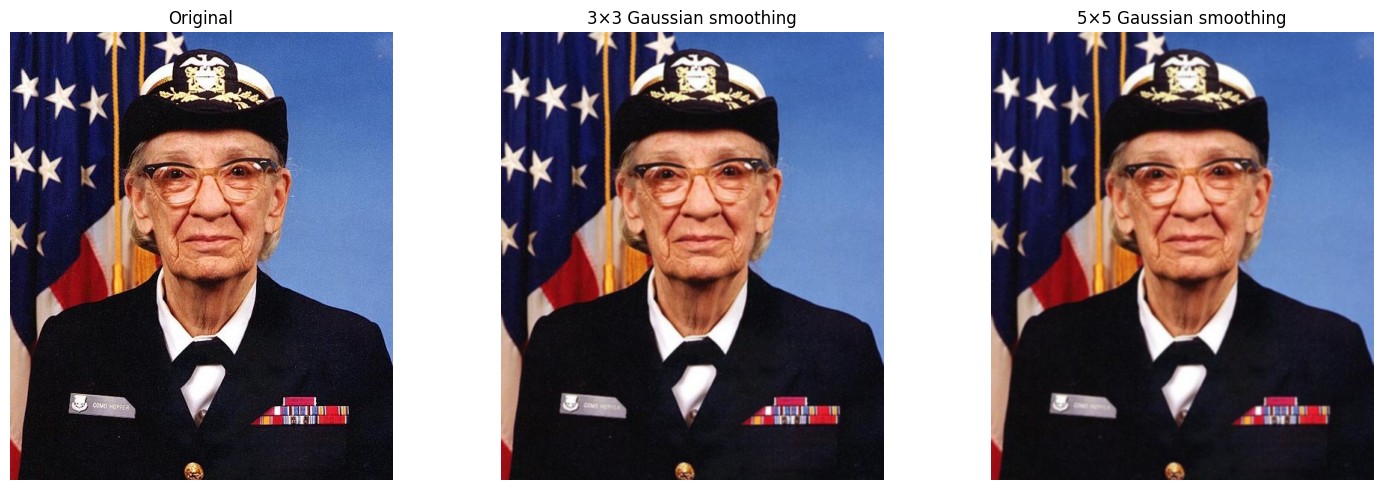

In [3]:

gaussian_3x3 = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

v = np.array([1, 4, 6, 4, 1], dtype=np.float32)
gaussian_5x5 = np.outer(v, v)
gaussian_5x5 /= gaussian_5x5.sum()

smooth_3 = convolve_rgb(image, gaussian_3x3)
smooth_5 = convolve_rgb(image, gaussian_5x5)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original")

axes[1].imshow(smooth_3)
axes[1].set_title("3×3 Gaussian smoothing")

axes[2].imshow(smooth_5)
axes[2].set_title("5×5 Gaussian smoothing")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()



### Answer

I would use a **Gaussian low-pass filter**. It replaces each pixel with a weighted average of nearby pixels, giving the greatest weight to the center. This suppresses small, abrupt intensity changes and can make fine wrinkles or minor blemishes less visible. A 3 × 3 kernel gives mild smoothing, while a 5 × 5 or larger kernel produces stronger smoothing but also increases blur.



## 3. When to Choose a Larger vs. Smaller Filter

The **filter size** determines how much of the surrounding image a convolution examines at one time.

### Smaller filter, such as 3 × 3
Choose a smaller filter when:

- fine details, edges, and local texture are important;
- you want fewer trainable parameters and lower computation;
- you want to stack several convolutional layers to gradually increase the receptive field;
- the task requires precise localization.

For example, a 3 × 3 filter is effective for detecting small edges, corners, and texture patterns.

### Larger filter, such as 5 × 5, 7 × 7, or larger
Choose a larger filter when:

- the feature of interest covers a wider area;
- broader spatial context is important;
- stronger smoothing is desired;
- the input is large and early aggregation of information is useful.

The disadvantage is that larger filters require more computation and, in a CNN, more parameters.

For the same number of input and output channels, one 5 × 5 convolution uses \(25C^2\) weights, while two stacked 3 × 3 convolutions use approximately \(18C^2\) weights and still provide an effective 5 × 5 receptive field. The stacked 3 × 3 layers can also include an extra nonlinear activation.



## 4. When to Choose a Larger vs. Smaller Stride

The **stride** is the number of pixels the filter moves at each convolution step.

### Smaller stride, usually stride = 1
Use a smaller stride when:

- preserving spatial resolution is important;
- small objects or fine image details must not be skipped;
- dense feature extraction is needed;
- the model will perform its downsampling later.

A stride of 1 evaluates the filter at nearly every image location.

### Larger stride, such as stride = 2
Use a larger stride when:

- you intentionally want to reduce the feature-map dimensions;
- faster computation and lower memory use are important;
- exact pixel-level localization is less important;
- the current layer is being used as a learnable downsampling stage.

For example, with SAME padding, a 256 × 256 feature map becomes approximately 128 × 128 when stride = 2.

### Trade-off

A **small stride preserves information but costs more computation**. A **large stride reduces computation and increases the effective receptive-field growth, but may discard fine details**.



# 5. CNN Calculations

Given:

- Original image: \(1028\times512\)
- Resized input: \(256\times256\)
- Assumed input channels: **3 (RGB)**
- `padding = true` → **SAME padding**
- C1: \(4\times4\), 100 filters, stride 1
- C2: \(4\times4\), 50 filters, stride 2
- C3: \(3\times3\), 50 filters, stride 1
- C4: \(4\times4\), 100 filters, stride 1
- C5: \(3\times3\), 100 filters, stride 1
- FC6: 2048 neurons
- Output: 10 classes



## 5(a). Size of Each Feature Map, C1 to C5

For SAME padding:

\[
H_{out}=\left\lceil\frac{H_{in}}{S}\right\rceil,\qquad
W_{out}=\left\lceil\frac{W_{in}}{S}\right\rceil
\]

The depth of the output feature map is equal to the **number of filters**.

### C1

Input:

\[
256\times256\times3
\]

Stride \(=1\), 100 filters:

\[
H_{out}=\left\lceil\frac{256}{1}\right\rceil=256
\]

\[
W_{out}=\left\lceil\frac{256}{1}\right\rceil=256
\]

Therefore:

\[
\boxed{C1=256\times256\times100}
\]

### C2

Input:

\[
256\times256\times100
\]

Stride \(=2\), 50 filters:

\[
H_{out}=\left\lceil\frac{256}{2}\right\rceil=128
\]

\[
W_{out}=\left\lceil\frac{256}{2}\right\rceil=128
\]

Therefore:

\[
\boxed{C2=128\times128\times50}
\]

### C3

Input:

\[
128\times128\times50
\]

Stride \(=1\), 50 filters:

\[
\boxed{C3=128\times128\times50}
\]

### C4

Input:

\[
128\times128\times50
\]

Stride \(=1\), 100 filters:

\[
\boxed{C4=128\times128\times100}
\]

### C5

Input:

\[
128\times128\times100
\]

Stride \(=1\), 100 filters:

\[
\boxed{C5=128\times128\times100}
\]

### Final feature-map summary

| Layer | Kernel | Stride | SAME Padding | Output Feature Map |
|---|---:|---:|---:|---:|
| Input | — | — | — | 256 × 256 × 3 |
| C1 | 4 × 4 | 1 | Yes | **256 × 256 × 100** |
| C2 | 4 × 4 | 2 | Yes | **128 × 128 × 50** |
| C3 | 3 × 3 | 1 | Yes | **128 × 128 × 50** |
| C4 | 4 × 4 | 1 | Yes | **128 × 128 × 100** |
| C5 | 3 × 3 | 1 | Yes | **128 × 128 × 100** |


In [4]:

import math

layers = [
    ("C1", 4, 4, 100, 1),
    ("C2", 4, 4, 50, 2),
    ("C3", 3, 3, 50, 1),
    ("C4", 4, 4, 100, 1),
    ("C5", 3, 3, 100, 1),
]

h, w, channels = 256, 256, 3

print(f"{'Layer':<6}{'Output shape':<24}")
print("-" * 30)

for name, kh, kw, filters, stride in layers:
    h = math.ceil(h / stride)
    w = math.ceil(w / stride)
    channels = filters
    print(f"{name:<6}{str((h, w, channels)):<24}")


Layer Output shape            
------------------------------
C1    (256, 256, 100)         
C2    (128, 128, 50)          
C3    (128, 128, 50)          
C4    (128, 128, 100)         
C5    (128, 128, 100)         



## 5(b). Total Number of Trainable Weights Including Biases

For a convolutional layer:

\[
\text{Parameters}
=
(K_h K_w C_{in} C_{out}) + C_{out}
\]

The final \(+C_{out}\) is the bias term: one bias per output filter.

For a fully connected layer:

\[
\text{Parameters}
=
N_{in}N_{out}+N_{out}
\]

### C1

\[
(4\times4\times3\times100)+100
=4{,}800+100
=\boxed{4{,}900}
\]

### C2

C2 receives 100 channels from C1:

\[
(4\times4\times100\times50)+50
=80{,}000+50
=\boxed{80{,}050}
\]

### C3

\[
(3\times3\times50\times50)+50
=22{,}500+50
=\boxed{22{,}550}
\]

### C4

\[
(4\times4\times50\times100)+100
=80{,}000+100
=\boxed{80{,}100}
\]

### C5

\[
(3\times3\times100\times100)+100
=90{,}000+100
=\boxed{90{,}100}
\]

### Flatten C5 before FC6

C5 has:

\[
128\times128\times100
=1{,}638{,}400
\]

features.

### FC6

\[
(1{,}638{,}400\times2{,}048)+2{,}048
\]

\[
=3{,}355{,}443{,}200+2{,}048
=\boxed{3{,}355{,}445{,}248}
\]

### Output Layer

FC6 has 2,048 outputs and there are 10 classes:

\[
(2{,}048\times10)+10
=20{,}480+10
=\boxed{20{,}490}
\]

### Grand Total

\[
4{,}900
+80{,}050
+22{,}550
+80{,}100
+90{,}100
+3{,}355{,}445{,}248
+20{,}490
\]

\[
\boxed{3{,}355{,}743{,}438\text{ trainable parameters}}
\]

The unusually large parameter count is caused by directly flattening the \(128\times128\times100\) C5 output into a 2,048-neuron fully connected layer. Modern CNNs commonly use additional downsampling or global average pooling before dense layers to avoid such a large parameter count.


In [5]:

# Verify the parameter count programmatically.

params = {}

params["C1"] = 4 * 4 * 3 * 100 + 100
params["C2"] = 4 * 4 * 100 * 50 + 50
params["C3"] = 3 * 3 * 50 * 50 + 50
params["C4"] = 4 * 4 * 50 * 100 + 100
params["C5"] = 3 * 3 * 100 * 100 + 100

flattened_c5 = 128 * 128 * 100
params["FC6"] = flattened_c5 * 2048 + 2048
params["Output"] = 2048 * 10 + 10

print(f"{'Layer':<10}{'Parameters':>18}")
print("-" * 28)
for layer, count in params.items():
    print(f"{layer:<10}{count:>18,}")
print("-" * 28)
print(f"{'TOTAL':<10}{sum(params.values()):>18,}")


Layer             Parameters
----------------------------
C1                     4,900
C2                    80,050
C3                    22,550
C4                    80,100
C5                    90,100
FC6            3,355,445,248
Output                20,490
----------------------------
TOTAL          3,355,743,438



### Note about the input channel assumption

The problem statement gives the resized spatial size \(256\times256\) but does not explicitly state whether the image is grayscale or RGB. The calculation above assumes **RGB**, which is the usual CNN image-input assumption.

If we intend a **grayscale** input, only C1 changes:

\[
(4\times4\times1\times100)+100=1{,}700
\]

and the total would become:

\[
\boxed{3{,}355{,}740{,}238}
\]

All feature-map spatial dimensions remain unchanged.



## 6. Advantages of CNN over MLP for Image Classification

A **Convolutional Neural Network (CNN)** is usually more suitable than a traditional **Multilayer Perceptron (MLP)** for image classification because a CNN is designed to exploit the spatial structure of images.

### Main advantages

1. **Local connectivity**  
   A CNN processes small neighboring regions instead of connecting every image pixel directly to every neuron. This allows it to learn local features such as edges, corners, and textures.

2. **Weight sharing**  
   The same convolution kernel is reused across the image. This greatly reduces the number of trainable parameters compared with a fully connected MLP.

3. **Preservation of spatial information**  
   CNNs retain the 2-D arrangement of pixels. A standard MLP normally requires an image to be flattened into a one-dimensional vector, which loses explicit spatial relationships.

4. **Hierarchical feature learning**  
   Early convolutional layers can learn simple patterns such as edges. Deeper layers combine them into textures, shapes, object parts, and eventually class-specific features.

5. **Better tolerance to translation**  
   Because the same filter scans different image locations, a CNN can detect a feature even when it appears in different positions.

6. **More computationally efficient for large images**  
   CNN parameter sharing makes image processing substantially more practical than a fully connected network operating directly on every pixel.

7. **Usually better generalization on vision tasks**  
   The CNN architecture builds in useful assumptions about images, so it generally needs fewer parameters than a comparable MLP and is less prone to overfitting solely because of huge fully connected input layers.

### Simple parameter comparison

A 256 × 256 RGB image contains:

\[
256\times256\times3=196{,}608
\]

input values.

If an MLP connected those values directly to only 2,048 hidden neurons:

\[
196{,}608\times2{,}048+2{,}048
=
402{,}655{,}232
\]

parameters would already be needed in its first dense layer.

In contrast, the first CNN layer in Question 5 uses only:

\[
4\times4\times3\times100+100
=
4{,}900
\]

parameters.

This illustrates why CNNs are much more parameter-efficient for image data.



# Summary of Final Answers

- **Q1:** Use an intensity gain \(g=\alpha f\): \(lpha>1\) brightens and \(0<lpha<1\) darkens.
- **Q2:** Use a Gaussian low-pass filter to smooth small wrinkles/blemishes; larger kernels smooth more strongly but blur more detail.
- **Q3:** Smaller filters preserve local detail and use fewer parameters; larger filters capture broader context but cost more computation.
- **Q4:** Smaller strides preserve spatial information; larger strides downsample and reduce computation but may skip details.
- **Q5(a):**  
  C1 = **256 × 256 × 100**  
  C2 = **128 × 128 × 50**  
  C3 = **128 × 128 × 50**  
  C4 = **128 × 128 × 100**  
  C5 = **128 × 128 × 100**
- **Q5(b):** Assuming RGB input, total trainable parameters including biases = **3,355,743,438**.
- **Q6:** CNNs are generally better suited to image classification because of local connectivity, weight sharing, spatial feature learning, hierarchical representations, and much better parameter efficiency than a fully connected MLP.
